# FULL PIPELINE SUBSTANCES CLASSIFICATION (PART 1)

Metals excluded

## 1. Molecular descriptors calculation (RDKit):

#### 1. Set-up:

In [260]:
## packages to install if required (remove hashtag and run):
#!pip install pysmiles
#!pip install descriptastorus
#!pip install rdkit

In [261]:
## import necessary libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from descriptastorus.descriptors.DescriptorGenerator import MakeGenerator

from PIL import Image
from pysmiles import read_smiles

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole, rdMolDraw2D
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors

import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [262]:
## export dataframe with substances + SMILES:
smiles_df = pd.read_csv('../data/contaminants_detected.csv', delimiter = ";")
smiles_df

,name,substance_type,CAS_nb,SMILES,detected,typol_class_tab_2
0,Carbaryl,insecticide,63-25-2,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0
1,Chlorpyrifos,insecticide,2921-88-2,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0
2,Cypermethrine,insecticide,52315-07-8,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0
3,DDD(2-4),insecticide,72-54-8,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0
4,Dicofol,insecticide,115-32-2,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN
...,...,...,...,...,...,...
70,NaN,NaN,NaN,NaN,NaN,NaN
71,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,NaN
73,NaN,NaN,NaN,NaN,NaN,NaN


In [263]:
## data cleaning:
print(f"Length of database with NAs: {len(smiles_df.SMILES)}")

if smiles_df.SMILES.isna().sum() > 0:
    smiles_cleaned = smiles_df.loc[smiles_df.SMILES.notna()].copy() ## remove NAs (cannot compute molecular descriptor if no SMILES structure present)
    print(f"Length of database without NAs (cleaned version): {len(smiles_cleaned.SMILES)}")
else:
    None

smiles_cleaned = smiles_cleaned.drop("CAS_nb", axis = 1).copy()

Length of database with NAs: 75
Length of database without NAs (cleaned version): 43


In [264]:
smiles_cleaned

,name,substance_type,SMILES,detected,typol_class_tab_2
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN


In [265]:
## extract list of molecules from their SMILES:
smiles_list = smiles_cleaned.SMILES

mol_list = []

for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    mol_list.append(mol)

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,

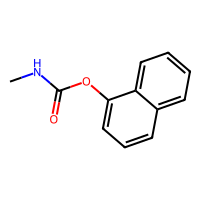
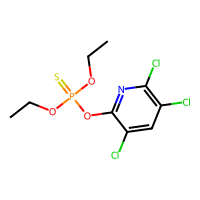
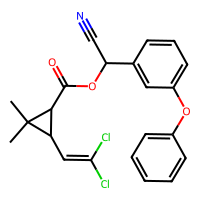
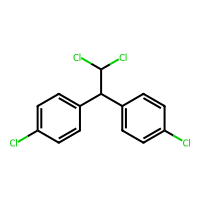
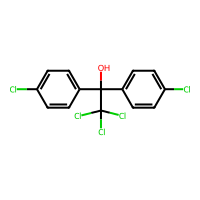
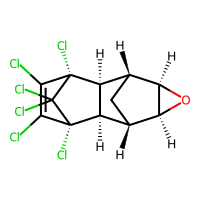
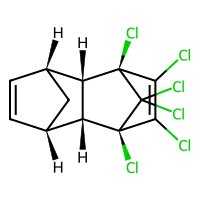
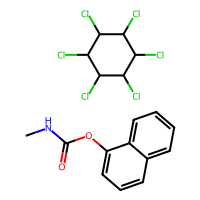
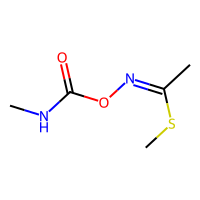
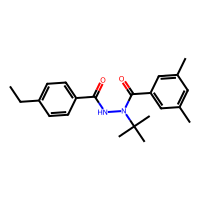
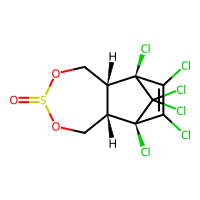
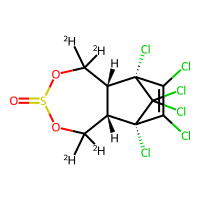
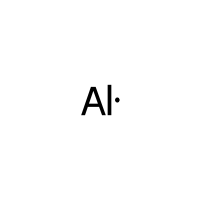
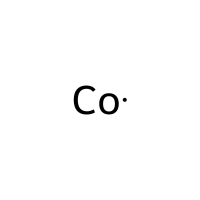
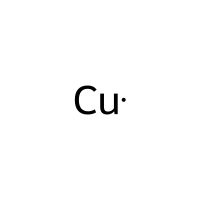
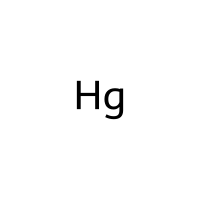
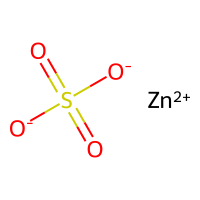
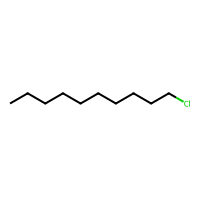
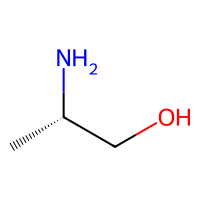
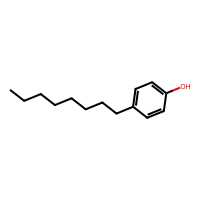
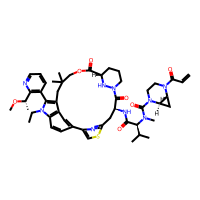
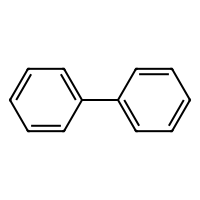
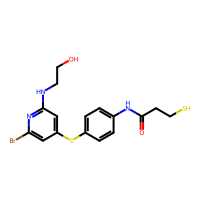
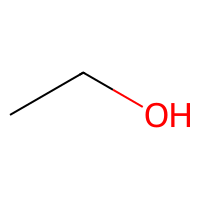
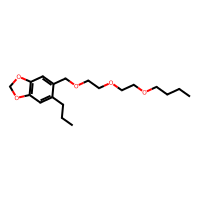
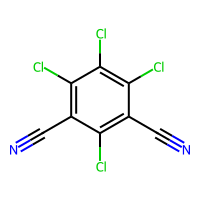
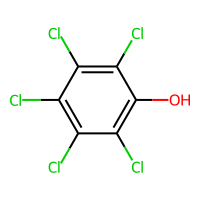
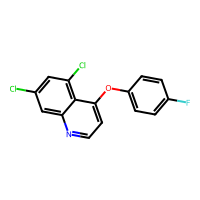
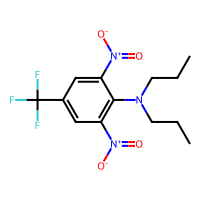
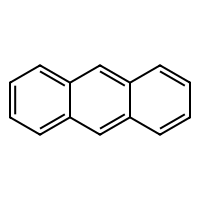
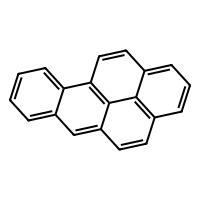
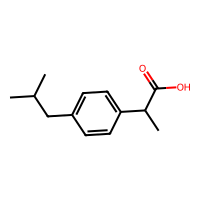
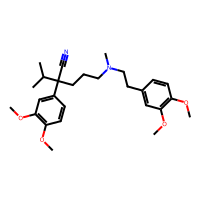
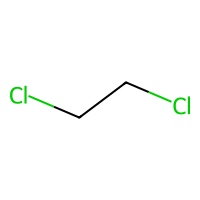
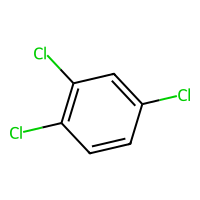
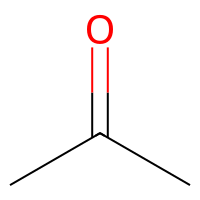
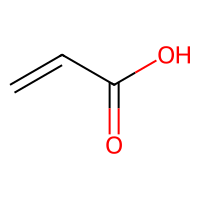
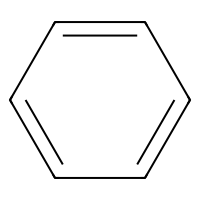
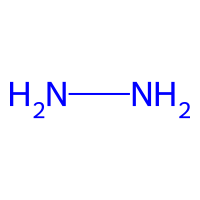
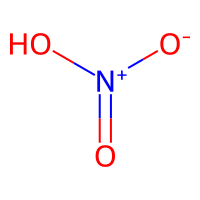
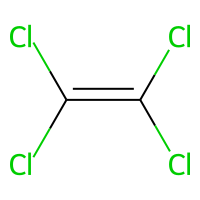
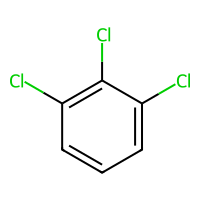
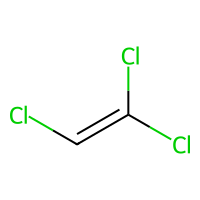

In [266]:
## add molecule column to df:
PandasTools.AddMoleculeColumnToFrame(smiles_cleaned, "SMILES", "molecule", includeFingerprints = True)
smiles_cleaned.molecule = mol_list
smiles_cleaned

#### 2. Basic chemical analysis of database:

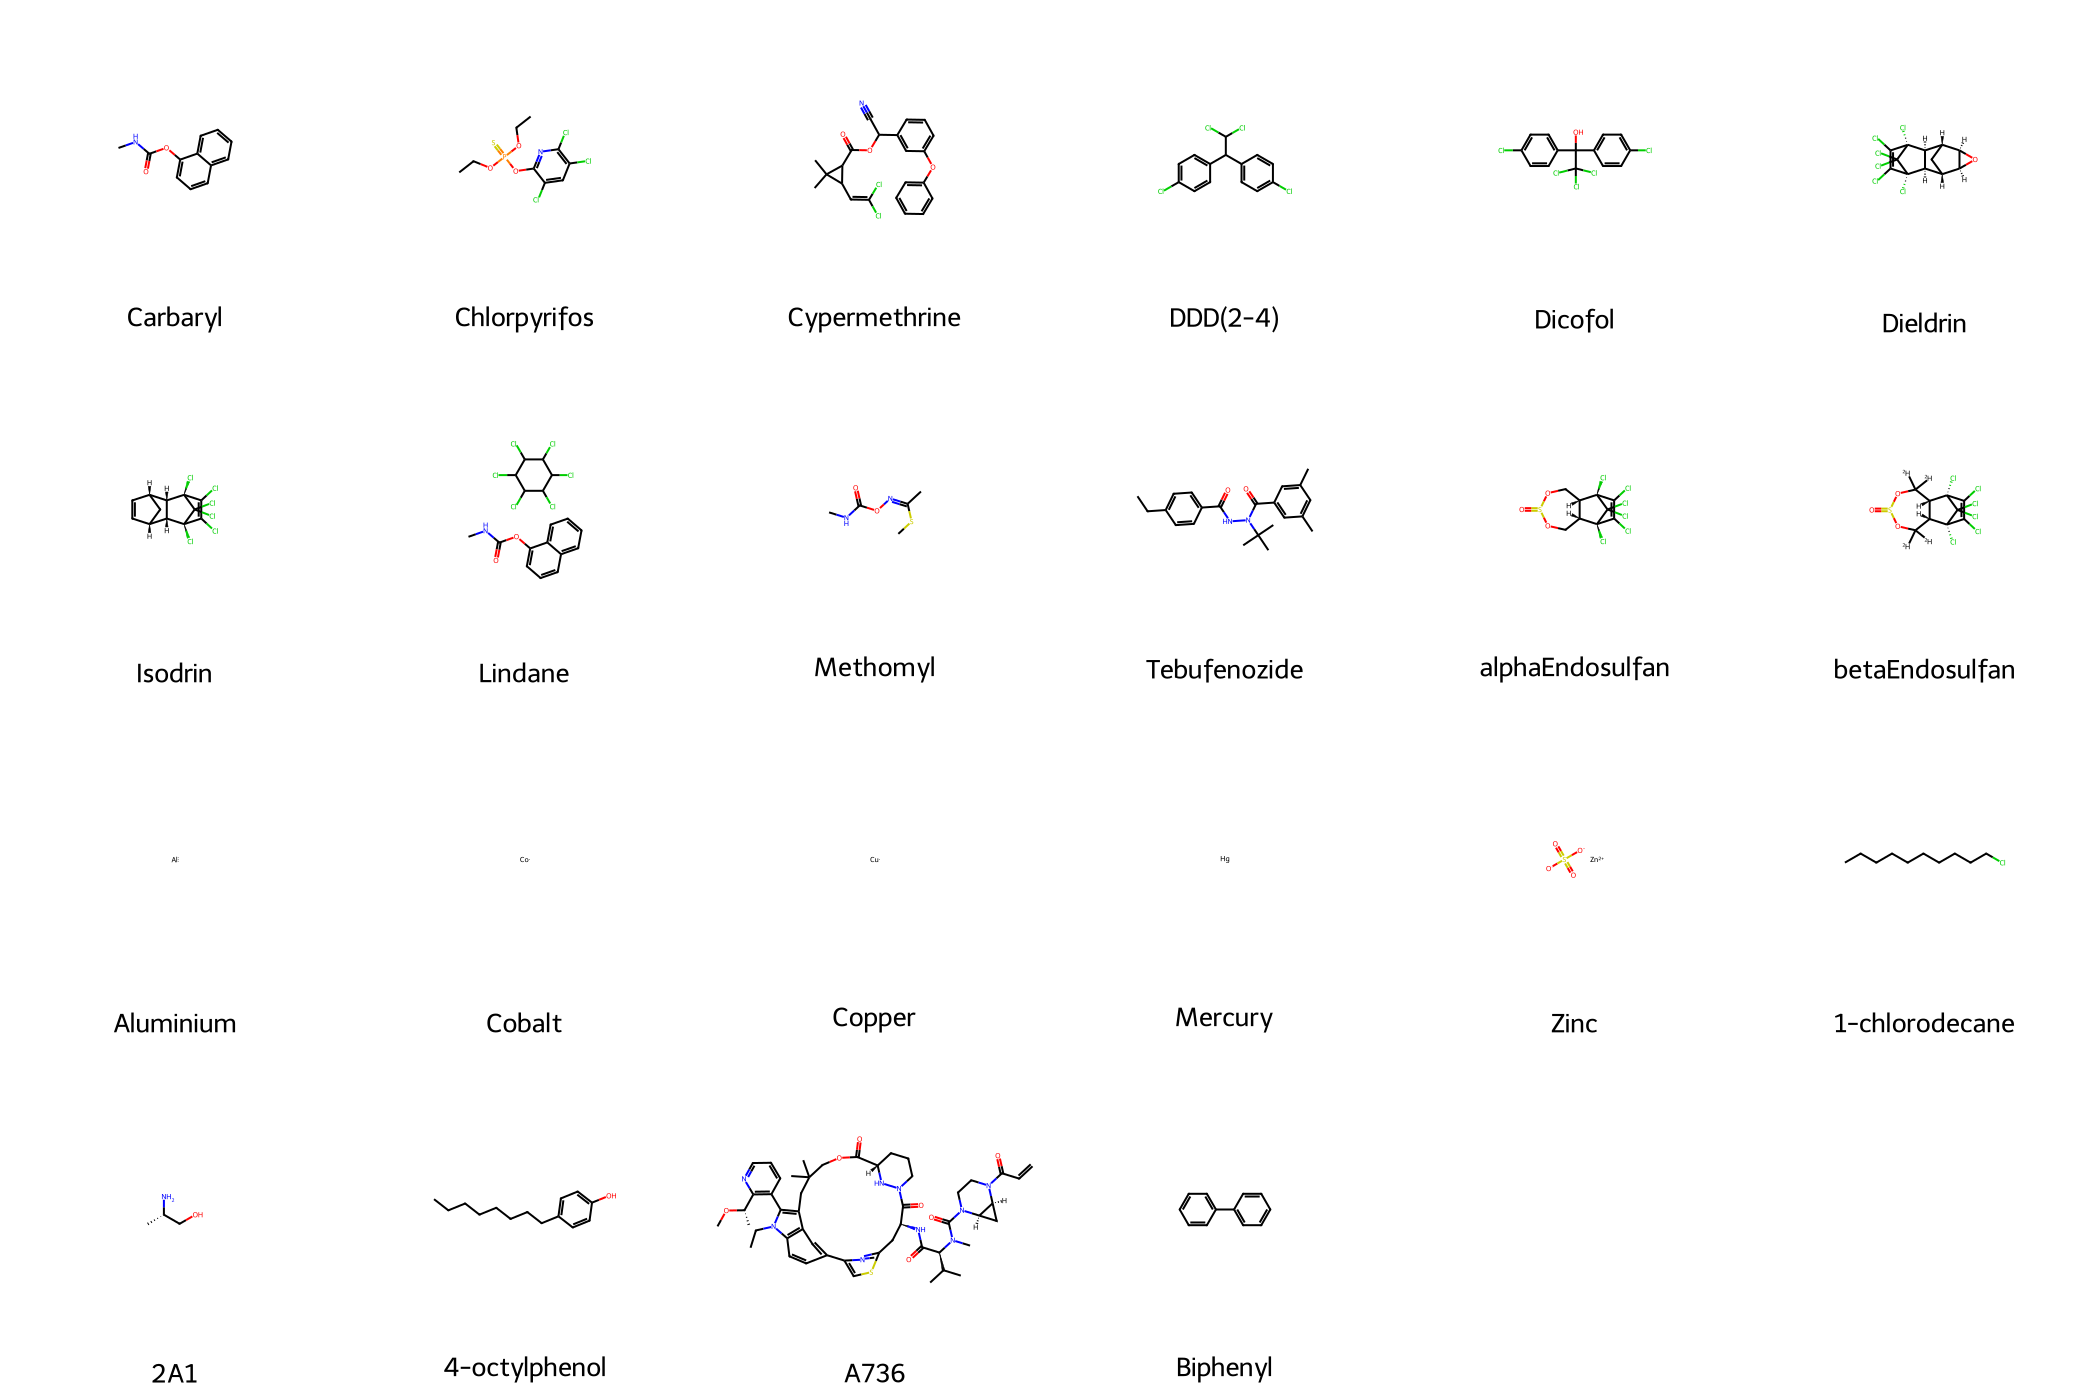

In [267]:
## visualise 2D rep of substances from their SMILES (just to see, for fun):
opts = rdMolDraw2D.MolDrawOptions()
opts.legendFontSize = 26

pic = Draw.MolsToGridImage(mol_list[0:22], molsPerRow = 6, maxMols = 70, subImgSize = (350, 350), legends = list(smiles_cleaned.name[0:22]), returnPNG = False, drawOptions=opts)
pic

In [268]:
## save molecular visualisation of present substances:
pic = Image.open("../plots/2d_rep_mols_1.png")
scale = 0.75
pic_res = pic.resize((int(pic.width*scale), int(pic.height*scale)), Image.LANCZOS)
pic_res.save("../plots/2d_rep_mols_1_compressed.png", optimize=True, compress_level=9) ## make a file called "plots" (or another name, but change it) to save image in

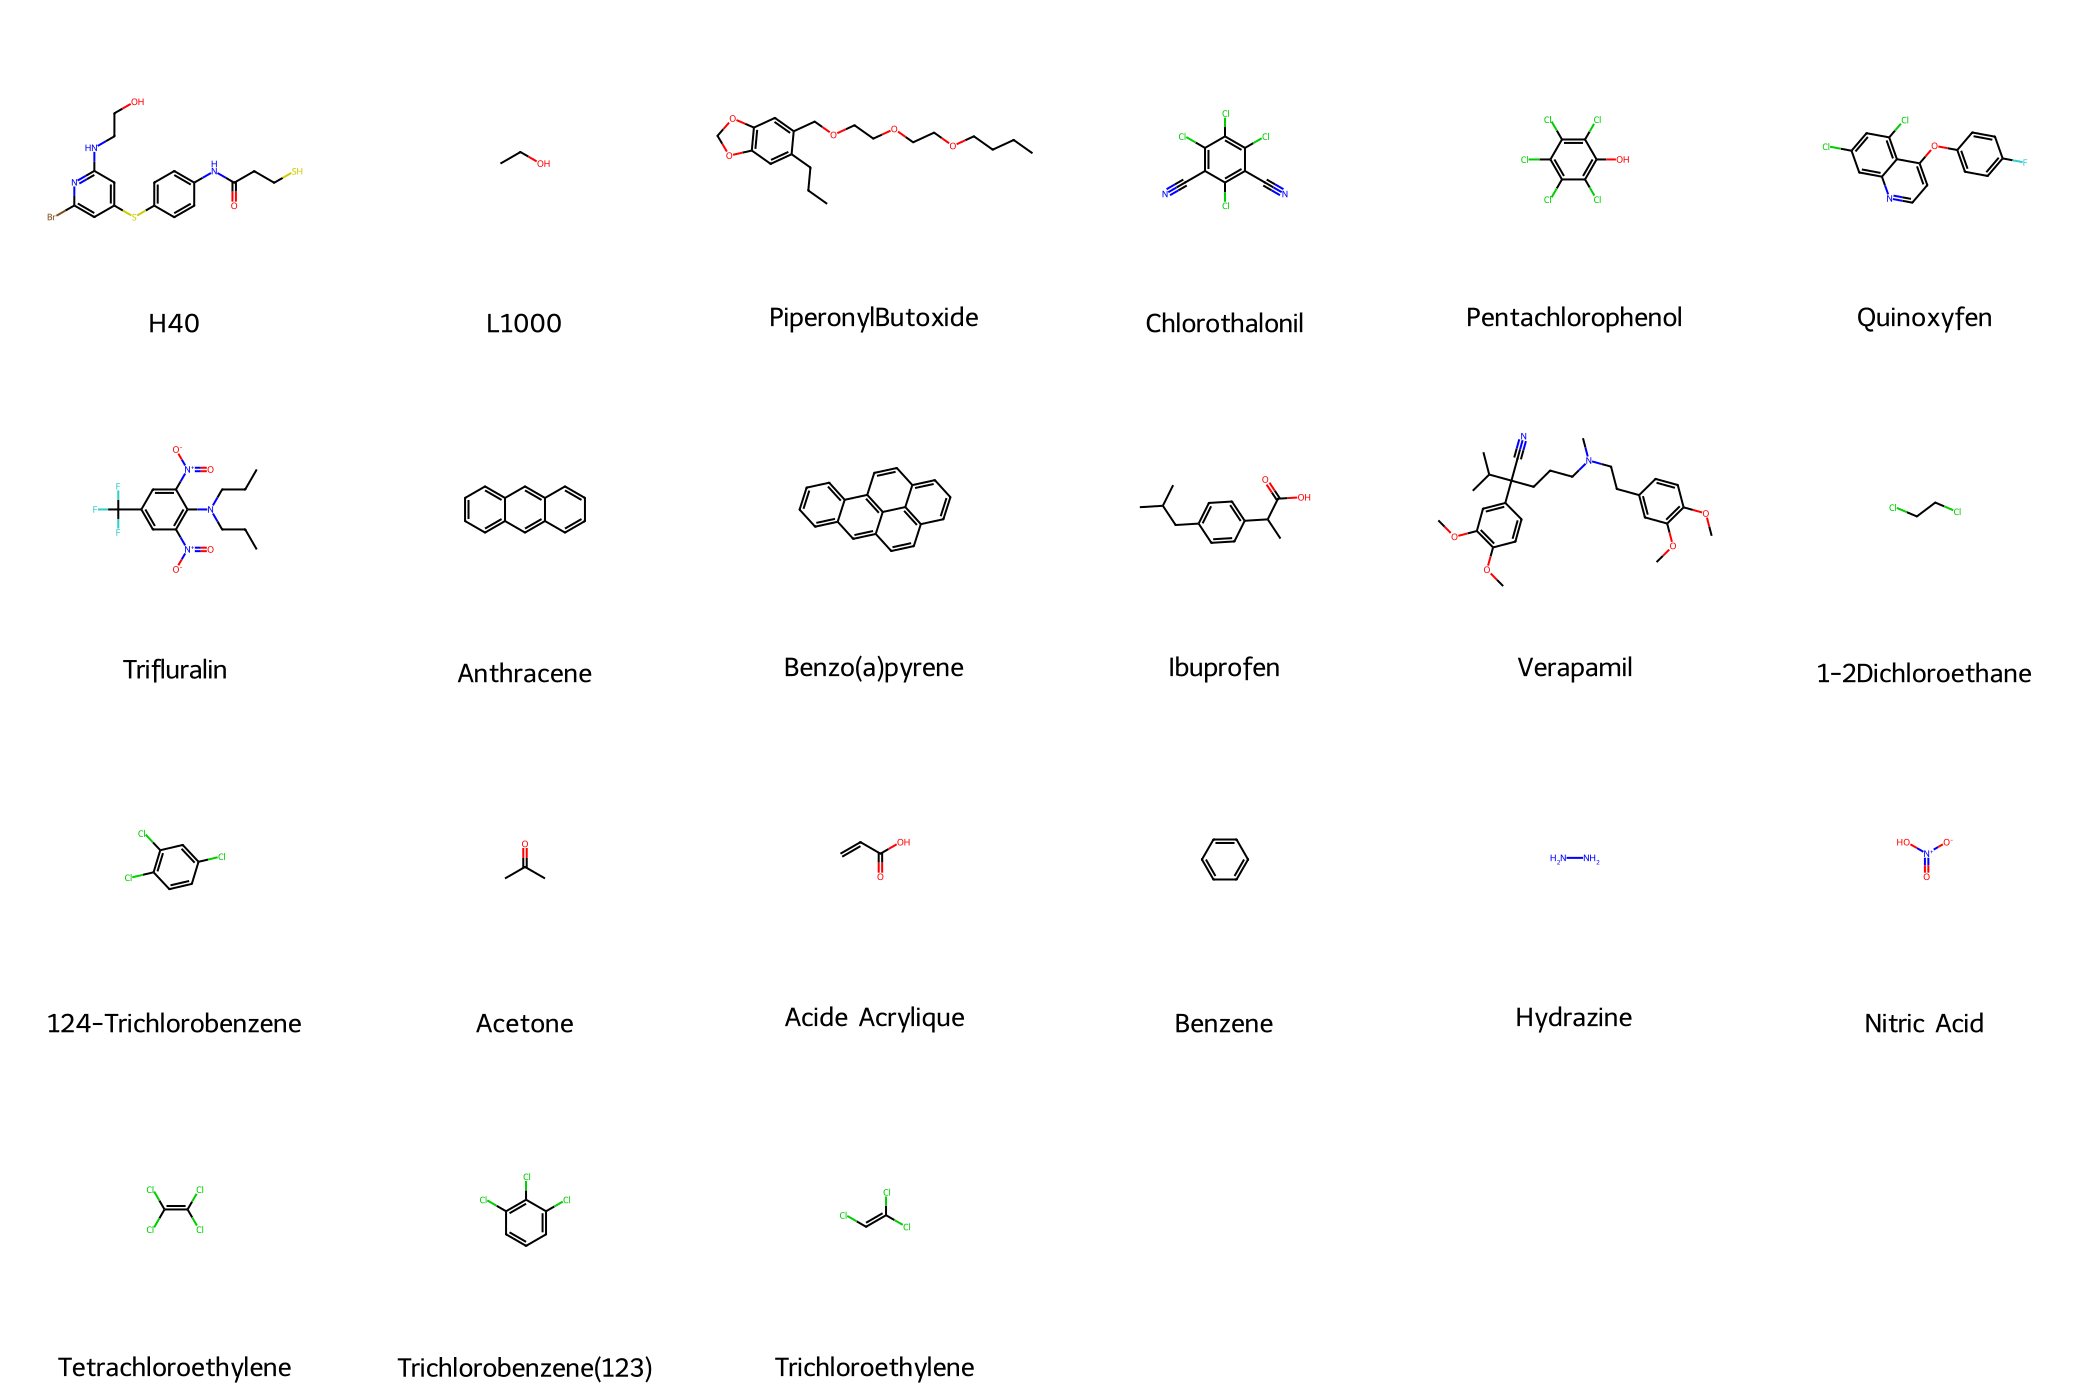

In [269]:
## visualise 2D rep of substances from their SMILES (just to see, for fun):
opts = rdMolDraw2D.MolDrawOptions()
opts.legendFontSize = 26

pic = Draw.MolsToGridImage(mol_list[22:], molsPerRow = 6, maxMols = 70, subImgSize = (350, 350), legends = list(smiles_cleaned.name[22:]), returnPNG = False, drawOptions=opts)
pic

In [270]:
## save molecular visualisation of present substances:
pic = Image.open("../plots/2d_rep_mols_2.png")
scale = 0.75
pic_res = pic.resize((int(pic.width*scale), int(pic.height*scale)), Image.LANCZOS)
pic_res.save("../plots/2d_rep_mols_2_compressed.png", optimize=True, compress_level=9) ## make a file called "plots" (or another name, but change it) to save image in

#### 3. Calculation of molecular descriptors:

In [271]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)
names = Desc_list_func.GetDescriptorNames()

In [272]:
des = []

for mol in smiles_cleaned["molecule"]:
  des.append(Desc_list_func.CalcDescriptors(mol))

rdkit_df = pd.concat([smiles_cleaned.reset_index(drop = True), pd.DataFrame(des).reset_index(drop = True)], axis = 1)
rdkit_df

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960c970>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960d540>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x32960f530>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960f840>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960f990>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e730>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e650>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960e570>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960de70>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960dee0>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


#### 4. Cleaning of MD db (check NAs, replace NAs, etc):

In [273]:
condition = rdkit_df.iloc[:, 6:223].isna().sum() ## set condition on NA nb threshold

nas_replace = condition[(condition > 0) & (condition <= 10)].index ## indexes of cols where there is less than 10 NAs

rdkit_df[nas_replace] = rdkit_df[nas_replace].fillna(0) ## replace NA values with 0
rdkit_df ## check db & how it looks like now

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960c970>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960d540>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x32960f530>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960f840>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960f990>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e730>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e650>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960e570>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960de70>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960dee0>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


In [274]:
## check if there's still NAs present or not
rdkit_df.all().isna().sum() ## 0

0

#### 5. Export results to .csv file:

In [275]:
rdkit_df.to_csv("../data/rdkit_descriptors_nomet.csv", index = False)

## 2. Preparation molecular descriptors database

* Data preprocessing on Mordred and RDKit databases to then perform clustering on them
* Removal/Replacement of NAs (if any present)
* Variance threshold (set a min variance to not take into account $\Rightarrow$ little info if $\mathbb{V}[X_i] \rightarrow 0$ (with $X_i$ a molecular descriptor and $i = 1, ..., N$, $N$ the number of molecular descriptors))
* Correlation plot (heatmap with the package seaborn): remove highly correlated molecular descriptors (to avoid columns that resemble each other and therefore remove any noise in the db so that it is ready to run models on it, whether it is a stat/ML/DL model)


#### 0. Initialise

In [276]:
## libraries to import
from scipy import stats

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from cmcrameri import cm
import seaborn as sns
%matplotlib inline

In [277]:
sns.set(style = 'white', context = 'notebook', rc = {'figure.figsize':(14, 10)})

#### 1. Import db:

In [278]:
data2 = pd.read_csv("../data/rdkit_descriptors_nomet.csv", delimiter = ",")
data2

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960c970>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960d540>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x32960f530>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960f840>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960f990>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e730>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e650>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960e570>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960de70>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960dee0>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


In [279]:
## remove metals:
rdkit_no_met = data2.drop(data2[data2["substance_type"]=="metal"].index)
rdkit_no_met

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,Carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960c970>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,Chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960d540>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,Cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x32960f530>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x32960f840>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,Dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960f990>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,Dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e730>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,Isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x32960e650>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,Lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x32960e570>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,Methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960de70>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,Tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x32960dee0>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


In [280]:
## get only mol. descr.:
rdkit_no_met.index = rdkit_no_met.name
rdkit_md = rdkit_no_met.drop({"name", "substance_type", "SMILES", "detected", "molecule", "typol_class_tab_2"}, axis = 1)
rdkit_md

,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,11.091562,11.091562,0.452451,-0.452451,0.769567,9.933333,201.225000,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
Chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,0.548341,11.611111,350.591000,339.503,348.926284,102,...,0,0,0,0,0,0,0,0,0,0
Cypermethrine,12.611418,12.611418,0.113804,-1.028401,0.528047,20.392857,416.304000,397.152,415.074199,144,...,0,0,0,0,0,0,0,0,0,0
DDD(2-4),6.091872,6.091872,0.094568,-0.534860,0.615021,11.222222,320.046000,309.966,317.953661,94,...,0,0,0,0,0,0,0,0,0,0
Dicofol,10.990246,10.990246,0.420576,-1.963632,0.682416,12.500000,370.490000,361.418,367.909603,106,...,0,0,0,0,0,0,0,0,0,0
Dieldrin,6.824159,6.824159,0.046682,-1.374691,0.342678,66.631579,380.913000,372.849,377.870631,104,...,0,0,0,0,0,0,0,0,0,0
Isodrin,6.761998,6.761998,0.066358,-1.365525,0.311830,58.777778,364.914000,356.850,361.875716,98,...,0,0,0,0,0,0,0,0,0,0
Lindane,11.091562,11.091562,0.436728,-0.452451,0.481974,30.185185,492.057000,474.921,488.939045,148,...,0,0,0,0,0,0,0,0,0,0
Methomyl,10.382504,10.382504,0.547778,-0.547778,0.271082,10.900000,162.214000,152.134,162.046299,58,...,1,0,0,0,0,0,0,0,0,0


In [281]:
## check if inf values in data:
print(f"Number of infinite values in RDKit database: {np.isinf(rdkit_md).sum().sum()}")

Number of infinite values in RDKit database: 0


In [282]:
rdkit_clean = rdkit_md[np.abs(stats.zscore(rdkit_md.iloc[:, 5])) < 3]
rdkit_clean

,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,11.091562,11.091562,0.452451,-0.452451,0.769567,9.933333,201.225000,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
Chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,0.548341,11.611111,350.591000,339.503,348.926284,102,...,0,0,0,0,0,0,0,0,0,0
Cypermethrine,12.611418,12.611418,0.113804,-1.028401,0.528047,20.392857,416.304000,397.152,415.074199,144,...,0,0,0,0,0,0,0,0,0,0
DDD(2-4),6.091872,6.091872,0.094568,-0.534860,0.615021,11.222222,320.046000,309.966,317.953661,94,...,0,0,0,0,0,0,0,0,0,0
Dicofol,10.990246,10.990246,0.420576,-1.963632,0.682416,12.500000,370.490000,361.418,367.909603,106,...,0,0,0,0,0,0,0,0,0,0
Isodrin,6.761998,6.761998,0.066358,-1.365525,0.311830,58.777778,364.914000,356.850,361.875716,98,...,0,0,0,0,0,0,0,0,0,0
Lindane,11.091562,11.091562,0.436728,-0.452451,0.481974,30.185185,492.057000,474.921,488.939045,148,...,0,0,0,0,0,0,0,0,0,0
Methomyl,10.382504,10.382504,0.547778,-0.547778,0.271082,10.900000,162.214000,152.134,162.046299,58,...,1,0,0,0,0,0,0,0,0,0
Tebufenozide,13.074419,13.074419,0.219603,-0.561752,0.829715,11.153846,352.478000,324.254,352.215078,138,...,0,0,0,0,0,0,0,0,0,0


#### 3 - Variance Threshold:

* Computes variance for each column;
* Set a threshold;
* If variance is lower than the threshold, don't select the column as the molecular descriptor contains little info and would not be useful for the analysis;
* Helps in reducing noise in database


In [283]:
selector = VarianceThreshold(threshold = 0.05)
var_reduced2 = selector.fit_transform(rdkit_clean)

In [284]:
## transform to df (so it can be used more easily afterwards):
rdkit_var = pd.DataFrame(var_reduced2, index = rdkit_clean.index, columns = selector.get_feature_names_out())
rdkit_var.head(6)

,0,1,2,3,5,6,7,8,9,15,...,176,177,187,189,190,191,197,198,205,215
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,11.091562,11.091562,0.452451,-0.452451,9.933333,201.225,190.137,201.078979,76.0,1.133333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,11.611111,350.591,339.503,348.926284,102.0,1.166667,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Cypermethrine,12.611418,12.611418,0.113804,-1.028401,20.392857,416.304,397.152,415.074199,144.0,1.142857,...,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
DDD(2-4),6.091872,6.091872,0.094568,-0.534860,11.222222,320.046,309.966,317.953661,94.0,0.611111,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dicofol,10.990246,10.990246,0.420576,-1.963632,12.500000,370.490,361.418,367.909603,106.0,0.650000,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Isodrin,6.761998,6.761998,0.066358,-1.365525,58.777778,364.914,356.850,361.875716,98.0,0.833333,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 4 - Standardise data:

In [285]:
scaler = StandardScaler()
rdkit_sc = scaler.fit_transform(rdkit_var)

In [286]:
rdkit_scaled = pd.DataFrame(rdkit_sc, columns=rdkit_var.columns, index=rdkit_clean.index)
rdkit_scaled.head(6)

,0,1,2,3,5,6,7,8,9,15,...,176,177,187,189,190,191,197,198,205,215
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,0.836553,0.836553,-0.116133,-0.089621,-0.363659,-0.330221,-0.340618,-0.325865,-0.148826,0.242712,...,-0.873500,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657
Chlorpyrifos,-0.660473,-0.660473,-0.654081,-1.761821,-0.239321,0.547246,0.585109,0.544928,0.274755,0.316795,...,0.511621,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,2.872281,-0.254657
Cypermethrine,1.278017,1.278017,-0.571202,-0.480170,0.411482,0.933284,0.942401,0.934527,0.959001,0.263878,...,0.049914,-0.297044,-0.203447,2.299219,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657
DDD(2-4),-0.615679,-0.615679,-0.597052,-0.145503,-0.268141,0.367806,0.402048,0.362505,0.144423,-0.917921,...,0.973329,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657
Dicofol,0.807124,0.807124,-0.158965,-1.114344,-0.173447,0.664144,0.720932,0.656736,0.339921,-0.831491,...,1.435036,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657
Isodrin,-0.421031,-0.421031,-0.634961,-0.708771,3.256138,0.631388,0.692621,0.621198,0.209589,-0.424035,...,1.896743,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657


In [287]:
## insert col sub_type again:
rdkit_scaled["substance_type"] = rdkit_scaled.index.map(rdkit_no_met['substance_type'])
rdkit_scaled.head(12)

,0,1,2,3,5,6,7,8,9,15,...,177,187,189,190,191,197,198,205,215,substance_type
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,0.836553,0.836553,-0.116133,-0.089621,-0.363659,-0.330221,-0.340618,-0.325865,-0.148826,0.242712,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Chlorpyrifos,-0.660473,-0.660473,-0.654081,-1.761821,-0.239321,0.547246,0.585109,0.544928,0.274755,0.316795,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,2.872281,-0.254657,insecticide
Cypermethrine,1.278017,1.278017,-0.571202,-0.480170,0.411482,0.933284,0.942401,0.934527,0.959001,0.263878,...,-0.297044,-0.203447,2.299219,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
DDD(2-4),-0.615679,-0.615679,-0.597052,-0.145503,-0.268141,0.367806,0.402048,0.362505,0.144423,-0.917921,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Dicofol,0.807124,0.807124,-0.158965,-1.114344,-0.173447,0.664144,0.720932,0.656736,0.339921,-0.831491,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Isodrin,-0.421031,-0.421031,-0.634961,-0.708771,3.256138,0.631388,0.692621,0.621198,0.209589,-0.424035,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Lindane,0.836553,0.836553,-0.137260,-0.089621,1.137179,1.378303,1.424391,1.369577,1.024167,-0.547506,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Methomyl,0.630597,0.630597,0.011967,-0.154262,-0.292021,-0.559396,-0.576149,-0.555761,-0.442074,1.502122,...,-0.297044,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide
Tebufenozide,1.412502,1.412502,-0.429031,-0.163738,-0.273209,0.558331,0.490600,0.564298,0.861251,-0.224581,...,3.366502,-0.203447,-0.278693,-0.166667,-0.166667,-0.239046,-0.239046,-0.348155,-0.254657,insecticide


#### 5 - Filter with correlation:

In [288]:
heatmap_df = rdkit_scaled.drop('substance_type', axis=1)

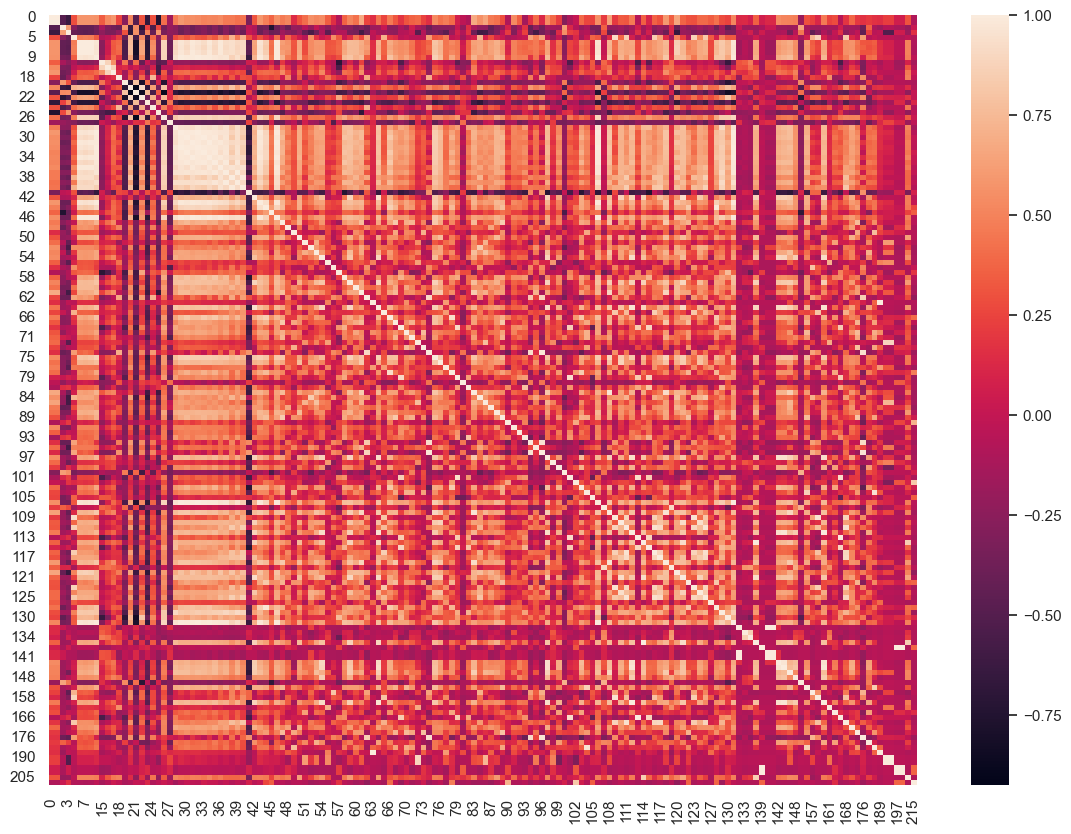

In [289]:
sns.heatmap(heatmap_df.corr())
plt.show()

In [290]:
## filter based on corr threshold:
corr_matrix = heatmap_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.95
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df_filtered = heatmap_df.drop(columns=to_drop)

In [291]:
df_filtered["substance_type"] = rdkit_scaled.substance_type.values
df_filtered.head(12)

,0,2,3,5,6,15,16,17,18,19,...,161,162,168,172,173,177,190,205,215,substance_type
name,,,,,,,,,,,,,,,,,,,,,
Carbaryl,0.836553,-0.116133,-0.089621,-0.363659,-0.330221,0.242712,0.973177,1.631762,-0.848453,-0.379772,...,-0.226134,-0.297044,0.038899,-0.239046,0.514187,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Chlorpyrifos,-0.660473,-0.654081,-1.761821,-0.239321,0.547246,0.316795,0.652249,0.809820,0.615620,0.098619,...,-0.226134,-0.297044,-0.440853,-0.239046,-0.391762,-0.297044,-0.166667,2.872281,-0.254657,insecticide
Cypermethrine,1.278017,-0.571202,-0.480170,0.411482,0.933284,0.263878,0.872667,1.257485,0.618716,-0.411343,...,-0.226134,-0.297044,-0.440853,4.183300,1.420136,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
DDD(2-4),-0.615679,-0.597052,-0.145503,-0.268141,0.367806,-0.917921,-1.075824,-1.039551,0.618731,-0.626561,...,-0.226134,-0.297044,-0.440853,-0.239046,-0.391762,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Dicofol,0.807124,-0.158965,-1.114344,-0.173447,0.664144,-0.831491,-1.063480,-1.080648,0.622078,-0.698102,...,-0.226134,-0.297044,-0.440853,-0.239046,-0.391762,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Isodrin,-0.421031,-0.634961,-0.708771,3.256138,0.631388,-0.424035,-0.458655,-0.320351,0.618810,-0.860677,...,-0.226134,-0.297044,3.876910,-0.239046,-0.391762,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Lindane,0.836553,-0.137260,-0.089621,1.137179,1.378303,-0.547506,-0.458655,-0.149113,0.616082,-0.566398,...,-0.226134,-0.297044,0.038899,-0.239046,0.514187,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Methomyl,0.630597,0.011967,-0.154262,-0.292021,-0.559396,1.502122,1.935961,1.693408,0.358131,0.660739,...,-0.226134,-0.297044,-0.440853,-0.239046,-0.391762,-0.297044,-0.166667,-0.348155,-0.254657,insecticide
Tebufenozide,1.412502,-0.429031,-0.163738,-0.273209,0.558331,-0.224581,0.073060,0.256589,-0.877491,-0.487962,...,-0.226134,5.198275,-0.440853,-0.239046,-0.391762,3.366502,-0.166667,-0.348155,-0.254657,insecticide


#### 6 - Save cleaned and filtered db in a .csv file:

In [292]:
## save cleaned & transformed db:
df_filtered.to_csv("../data/rdkit_clean_nomet.csv", index = True)